In [2088]:
import pandas as pd

In [2089]:
store = pd.read_csv("store.csv")
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")


C:\Users\MANH XU\AppData\Local\Temp\ipykernel_25716\3874914726.py:2: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


In [2090]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


- train k missing/duplicate

In [2091]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [2092]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


- Store missing nhiều, không duplicate

In [2093]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


### Merge data

In [2094]:
# 2. GỘP DỮ LIỆU (MERGE)

# Gộp Train và Store dựa trên cột 'Store'
train_merged = pd.merge(train, store, on='Store', how='left')

# Gộp Test và Store dựa trên cột 'Store'
test_merged = pd.merge(test, store, on='Store', how='left')

In [2095]:
train_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionOpenSinceYea

In [2096]:
train_merged['StateHoliday'].unique()

array(['0', 'a', 'b', 'c', 0], dtype=object)

In [2097]:
# 1. Chuyển Date về datetime 
train_merged['Date'] = pd.to_datetime(train_merged['Date'])

# 2. Chuẩn hóa StateHoliday về string để tránh lẫn lộn giữa số 0 và chữ '0'
# Lưu ý: .astype(str) sẽ biến NaN thành chuỗi 'nan', nên ta dùng cách map để giữ nguyên None/NaN
train_merged['StateHoliday'] = train_merged['StateHoliday'].map(lambda x: str(x) if pd.notnull(x) else x)

# 5. Kiểm tra lại
print(train_merged.info())
print("\nSố lượng giá trị thiếu (vẫn giữ nguyên):")
print(train_merged.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567 non-null  flo

In [2098]:
train_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567 non-null  flo

In [2099]:
train_merged

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [2100]:
# 1. Xem nhanh số lượng giá trị duy nhất của mỗi cột
print("--- SỐ LƯỢNG UNIQUE VALUES MỖI CỘT ---")
print(train_merged.nunique())
print("-" * 30)

# 2. Xem chi tiết giá trị duy nhất của từng cột
# Lưu ý: Tôi sẽ lọc để chỉ in ra chi tiết nếu cột đó có ít hơn 25 giá trị 
# để tránh làm tràn màn hình bởi các cột như Sales hoặc Date.

for col in train_merged.columns:
    unique_vals = train_merged[col].unique()
    num_unique = len(unique_vals)
    
    print(f"Cột: **{col}** | Số lượng unique: {num_unique}")
    
    if num_unique <= 25:
        print(f"  -> Các giá trị: {unique_vals}")
    else:
        print(f"  -> Giá trị: (Quá nhiều, chỉ in 5 mẫu): {unique_vals[:5]}")
    print("-" * 20)

--- SỐ LƯỢNG UNIQUE VALUES MỖI CỘT ---
Store                         1115
DayOfWeek                        7
Date                           942
Sales                        21734
Customers                     4086
Open                             2
Promo                            2
StateHoliday                     4
SchoolHoliday                    2
StoreType                        4
Assortment                       3
CompetitionDistance            654
CompetitionOpenSinceMonth       12
CompetitionOpenSinceYear        23
Promo2                           2
Promo2SinceWeek                 24
Promo2SinceYear                  7
PromoInterval                    3
dtype: int64
------------------------------
Cột: **Store** | Số lượng unique: 1115
  -> Giá trị: (Quá nhiều, chỉ in 5 mẫu): [1 2 3 4 5]
--------------------
Cột: **DayOfWeek** | Số lượng unique: 7
  -> Các giá trị: [5 4 3 2 1 7 6]
--------------------
Cột: **Date** | Số lượng unique: 942
  -> Giá trị: (Quá nhiều, chỉ in 5 mẫu): <

- Handle missing 

In [2101]:
# fill na values = 0
train_merged[['Promo2SinceWeek', 'Promo2SinceYear']] = train_merged[['Promo2SinceWeek', 'Promo2SinceYear']].fillna(0)
train_merged[['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']] = train_merged[['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']].fillna(0)

# fill 'CompetitionDistance' na values with median
median_competition_distance = train_merged['CompetitionDistance'].median()
train_merged['CompetitionDistance'] = train_merged['CompetitionDistance'].fillna(median_competition_distance)

#fill PromoInterval na values with 'None'

train_merged['PromoInterval'] = train_merged['PromoInterval'].fillna('None')

In [2102]:
from sklearn.impute import SimpleImputer

# 1. Khai báo các nhóm cột
cols_fill_zero = ['Promo2SinceWeek', 'Promo2SinceYear', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']
col_fill_median = ['CompetitionDistance']
col_fill_none = ['PromoInterval']

# 2. Tạo các Imputer (Bộ điền khuyết)
imputer_zero = SimpleImputer(strategy='constant', fill_value=0)
imputer_median = SimpleImputer(strategy='median')
imputer_none = SimpleImputer(strategy='constant', fill_value='None')

# 3. FIT trên tập Train (Máy sẽ "học" số Median ở bước này)
imputer_zero.fit(train_merged[cols_fill_zero])
imputer_median.fit(train_merged[col_fill_median])
imputer_none.fit(train_merged[col_fill_none])

# 4. TRANSFORM trên cả Train và Test (Dùng thông số đã học ở bước 3)
train_merged[cols_fill_zero] = imputer_zero.transform(train_merged[cols_fill_zero])
train_merged[col_fill_median] = imputer_median.transform(train_merged[col_fill_median])
train_merged[col_fill_none] = imputer_none.transform(train_merged[col_fill_none])

# Với tập Test (Chỉ dùng transform, tuyệt đối không fit)
test_merged[cols_fill_zero] = imputer_zero.transform(test_merged[cols_fill_zero])
test_merged[col_fill_median] = imputer_median.transform(test_merged[col_fill_median])
test_merged[col_fill_none] = imputer_none.transform(test_merged[col_fill_none])

In [2103]:
train_merged.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [2104]:
train_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1017209 non-null  flo

In [2105]:
train_merged['Promo2SinceYear'].unique()

array([   0., 2010., 2011., 2012., 2009., 2014., 2015., 2013.])

In [2106]:
train_merged['CompetitionOpenSinceMonth'] = train_merged['CompetitionOpenSinceMonth'].astype('int8')
train_merged['CompetitionOpenSinceYear'] = train_merged['CompetitionOpenSinceYear'].astype('int16')
train_merged['Promo2SinceWeek'] = train_merged['Promo2SinceWeek'].astype('int8')
train_merged['Promo2SinceYear'] = train_merged['Promo2SinceYear'].astype('int16')

In [2107]:
train_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1017209 non-null  flo

In [2108]:
# 1. Ép kiểu các cột phân loại 
cat_cols = ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']
for col in cat_cols:
    train_merged[col] = train_merged[col].astype('category')
# Kiểm tra lại thành quả
print(train_merged.info())

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  category      
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  category      
 10  Assortment                 1017209 non-null  category      
 11  CompetitionDistance        1017209 non-null  flo

In [2109]:
train_merged.duplicated().sum()

np.int64(0)

## Test_merged

In [2110]:
test_merged.isnull().sum()  

Id                            0
Store                         0
DayOfWeek                     0
Date                          0
Open                         11
Promo                         0
StateHoliday                  0
SchoolHoliday                 0
StoreType                     0
Assortment                    0
CompetitionDistance           0
CompetitionOpenSinceMonth     0
CompetitionOpenSinceYear      0
Promo2                        0
Promo2SinceWeek               0
Promo2SinceYear               0
PromoInterval                 0
dtype: int64

In [2111]:
test_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Id                         41088 non-null  int64  
 1   Store                      41088 non-null  int64  
 2   DayOfWeek                  41088 non-null  int64  
 3   Date                       41088 non-null  str    
 4   Open                       41077 non-null  float64
 5   Promo                      41088 non-null  int64  
 6   StateHoliday               41088 non-null  str    
 7   SchoolHoliday              41088 non-null  int64  
 8   StoreType                  41088 non-null  str    
 9   Assortment                 41088 non-null  str    
 10  CompetitionDistance        41088 non-null  float64
 11  CompetitionOpenSinceMonth  41088 non-null  float64
 12  CompetitionOpenSinceYear   41088 non-null  float64
 13  Promo2                     41088 non-null  int64  
 14  P

In [2112]:
test_merged['StoreType'].unique()

<StringArray>
['c', 'a', 'd', 'b']
Length: 4, dtype: str

In [2113]:
test_merged.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,0.0,0.0,None
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,0.0,0.0,None
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,0.0,0.0,None


- Các ngày open bị missing 
    + 2015-09-05: Thứ Bảy
    + 2015-09-07: Thứ Hai
    + 2015-09-08: Thứ Ba
    + 2015-09-09: Thứ Tư
    + 2015-09-10: Thứ Năm
    + 2015-09-11: Thứ Sáu
    + 2015-09-12: Thứ Bảy
    + 2015-09-14: Thứ Hai
    + 2015-09-15: Thứ Ba
    + 2015-09-16: Thứ Tư
    + 2015-09-17: Thứ Năm

- Có mỗi thằng 622 bị thiếu ngày open 

In [2114]:
#check missing Open
test_merged['Open'].isnull().sum()

np.int64(11)

In [2115]:
store[store['Store'] == 622]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN


In [2116]:
train[train['Store'] == 622]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
621,622,5,2015-07-31,6306,540,1,1,0,1
1736,622,4,2015-07-30,5412,406,1,1,0,1
2851,622,3,2015-07-29,5326,468,1,1,0,1
3966,622,2,2015-07-28,4966,417,1,1,0,1
5081,622,1,2015-07-27,5413,517,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1012256,622,6,2013-01-05,2350,258,1,0,0,0
1013371,622,5,2013-01-04,3675,399,1,0,0,1
1014486,622,4,2013-01-03,4085,419,1,0,0,1
1015601,622,3,2013-01-02,4080,451,1,0,0,1


In [2117]:
test_merged['Date'] = pd.to_datetime(test_merged['Date'])



In [2118]:
test_merged['Date'] = pd.to_datetime(test_merged['Date'])

# # 1. Điền Open cho Store 622 (11 ngày thiếu ta đã chứng minh là nên điền 1)
test_merged['Open'] = test_merged['Open'].fillna(1)

# 2. Điền CompetitionDistance bằng Median từ tập TRAIN (đã tính ở cell trước)
# # Nếu bạn lỡ làm mất biến đó, chạy lại: median_competition_distance = train_merged['CompetitionDistance'].median()
# test_merged['CompetitionDistance'] = test_merged['CompetitionDistance'].fillna(median_competition_distance)

# # 3. Điền 0 cho các cột thời gian (vì thiếu nghĩa là không có đối thủ/không promo2)
# cols_to_fill_zero = ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 
#                       'Promo2SinceWeek', 'Promo2SinceYear']
# test_merged[cols_to_fill_zero] = test_merged[cols_to_fill_zero].fillna(0)

# # 4. Điền 'None' cho PromoInterval
# test_merged['PromoInterval'] = test_merged['PromoInterval'].fillna('None')

In [2119]:
test_merged[test_merged['Open'].isnull()]

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval


In [2120]:
test_merged[test_merged['Open'] != 1]

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
543,544,703,4,2015-09-17,0.0,1,0,0,a,a,80.0,6.0,2005.0,0,0.0,0.0,None
676,677,879,4,2015-09-17,0.0,1,0,0,d,a,2330.0,0.0,0.0,1,5.0,2013.0,"Feb,May,Aug,Nov"
840,841,1097,4,2015-09-17,0.0,1,0,0,b,b,720.0,3.0,2002.0,0,0.0,0.0,None
1399,1400,703,3,2015-09-16,0.0,1,0,0,a,a,80.0,6.0,2005.0,0,0.0,0.0,None
1532,1533,879,3,2015-09-16,0.0,1,0,0,d,a,2330.0,0.0,0.0,1,5.0,2013.0,"Feb,May,Aug,Nov"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40227,40228,1111,7,2015-08-02,0.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
40228,40229,1112,7,2015-08-02,0.0,0,0,0,c,c,1880.0,4.0,2006.0,0,0.0,0.0,None
40229,40230,1113,7,2015-08-02,0.0,0,0,0,a,c,9260.0,0.0,0.0,0,0.0,0.0,None
40230,40231,1114,7,2015-08-02,0.0,0,0,0,a,c,870.0,0.0,0.0,0,0.0,0.0,None


In [2121]:
#chuyển kiểu cột Open sang int64
test_merged['Open'] = test_merged['Open'].astype('int64')

In [2122]:
test_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Id                         41088 non-null  int64         
 1   Store                      41088 non-null  int64         
 2   DayOfWeek                  41088 non-null  int64         
 3   Date                       41088 non-null  datetime64[us]
 4   Open                       41088 non-null  int64         
 5   Promo                      41088 non-null  int64         
 6   StateHoliday               41088 non-null  str           
 7   SchoolHoliday              41088 non-null  int64         
 8   StoreType                  41088 non-null  str           
 9   Assortment                 41088 non-null  str           
 10  CompetitionDistance        41088 non-null  float64       
 11  CompetitionOpenSinceMonth  41088 non-null  float64       
 12  CompetitionOpen

In [2123]:
test_merged['PromoInterval'].unique()

<StringArray>
['None', 'Jan,Apr,Jul,Oct', 'Feb,May,Aug,Nov', 'Mar,Jun,Sept,Dec']
Length: 4, dtype: str

In [2124]:
# 1. Ép kiểu số nguyên nhỏ (int8, int16)
test_merged['CompetitionOpenSinceMonth'] = test_merged['CompetitionOpenSinceMonth'].astype('int8')
test_merged['Promo2SinceWeek'] = test_merged['Promo2SinceWeek'].astype('int8')

# 2. Ép kiểu số nguyên vừa (int16, int32)
test_merged['Id'] = test_merged['Id'].astype('int32')
test_merged['CompetitionOpenSinceYear'] = test_merged['CompetitionOpenSinceYear'].astype('int16')
test_merged['Promo2SinceYear'] = test_merged['Promo2SinceYear'].astype('int16')

# 4. Ép kiểu Phân loại (Category)
# Lưu ý: StateHoliday cần ép về str trước để đồng nhất '0' và 0
test_merged['StateHoliday'] = test_merged['StateHoliday'].astype(str).astype('category')
test_merged['StoreType'] = test_merged['StoreType'].astype('category')
test_merged['Assortment'] = test_merged['Assortment'].astype('category')
test_merged['PromoInterval'] = test_merged['PromoInterval'].astype('category')

# KIỂM TRA LẠI
print(test_merged.info())

<class 'pandas.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Id                         41088 non-null  int32         
 1   Store                      41088 non-null  int64         
 2   DayOfWeek                  41088 non-null  int64         
 3   Date                       41088 non-null  datetime64[us]
 4   Open                       41088 non-null  int64         
 5   Promo                      41088 non-null  int64         
 6   StateHoliday               41088 non-null  category      
 7   SchoolHoliday              41088 non-null  int64         
 8   StoreType                  41088 non-null  category      
 9   Assortment                 41088 non-null  category      
 10  CompetitionDistance        41088 non-null  float64       
 11  CompetitionOpenSinceMonth  41088 non-null  int8          
 12  CompetitionOpen

In [2125]:
train_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  category      
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  category      
 10  Assortment                 1017209 non-null  category      
 11  CompetitionDistance        1017209 non-null  flo

In [2126]:
test_merged.duplicated().sum()

np.int64(0)

### Xong missing và duplicate 

In [2127]:
#Check những ngày cửa hàng mở cửa nhưng doanh số <= 0
train_merged[(train_merged['Open'] != 0) & (train_merged['Sales'] <= 0)].head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
86825,971,5,2015-05-15,0,0,1,0,0,1,c,a,1140.0,5,2011,1,14,2012,"Mar,Jun,Sept,Dec"
142278,674,4,2015-03-26,0,0,1,0,0,0,a,a,2640.0,12,2005,1,31,2013,"Feb,May,Aug,Nov"
196938,699,4,2015-02-05,0,0,1,1,0,0,a,a,180.0,0,0,1,5,2013,"Jan,Apr,Jul,Oct"
322053,708,3,2014-10-01,0,0,1,1,0,0,c,c,11470.0,10,2009,1,18,2014,"Jan,Apr,Jul,Oct"
330176,357,1,2014-09-22,0,0,1,0,0,0,a,a,2060.0,10,2008,0,0,0,None


In [2128]:
train_merged[(train_merged['Open'] != 0) & (train_merged['Sales'] <= 0)].count().sum()

np.int64(972)

In [2129]:
#đếm số ngày Open == 0
train_merged[train_merged['Open'] == 0].count()

Store                        172817
DayOfWeek                    172817
Date                         172817
Sales                        172817
Customers                    172817
Open                         172817
Promo                        172817
StateHoliday                 172817
SchoolHoliday                172817
StoreType                    172817
Assortment                   172817
CompetitionDistance          172817
CompetitionOpenSinceMonth    172817
CompetitionOpenSinceYear     172817
Promo2                       172817
Promo2SinceWeek              172817
Promo2SinceYear              172817
PromoInterval                172817
dtype: int64

In [2130]:
# Lọc tập Train: Chỉ giữ lại những ngày cửa hàng mở và có doanh số > 0
print(train_merged[(train_merged['Open'] != 0) & (train_merged['Sales'] > 0)].count())
train_merged = train_merged[(train_merged['Open'] != 0) & (train_merged['Sales'] > 0)]   

Store                        844338
DayOfWeek                    844338
Date                         844338
Sales                        844338
Customers                    844338
Open                         844338
Promo                        844338
StateHoliday                 844338
SchoolHoliday                844338
StoreType                    844338
Assortment                   844338
CompetitionDistance          844338
CompetitionOpenSinceMonth    844338
CompetitionOpenSinceYear     844338
Promo2                       844338
Promo2SinceWeek              844338
Promo2SinceYear              844338
PromoInterval                844338
dtype: int64


In [2131]:
train_merged.info()

<class 'pandas.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[us]
 3   Sales                      844338 non-null  int64         
 4   Customers                  844338 non-null  int64         
 5   Open                       844338 non-null  int64         
 6   Promo                      844338 non-null  int64         
 7   StateHoliday               844338 non-null  category      
 8   SchoolHoliday              844338 non-null  int64         
 9   StoreType                  844338 non-null  category      
 10  Assortment                 844338 non-null  category      
 11  CompetitionDistance        844338 non-null  float64       
 12  Com

In [2132]:
# có ngày nào mở cửa mà doanh số <= 0 nữa không?
train_merged[(train_merged['Open'] != 0) & (train_merged['Sales'] <= 0)].head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval


In [2133]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2134]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


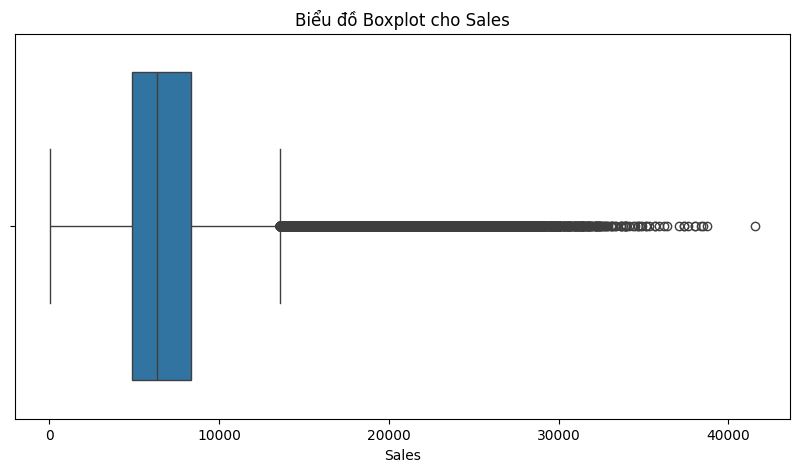

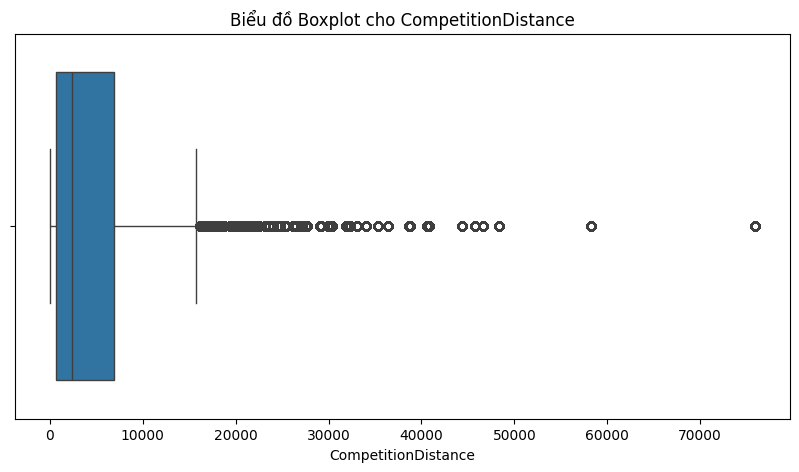

In [2135]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_outliers(df, column):
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[column])
    plt.title(f'Biểu đồ Boxplot cho {column}')
    plt.show()

# Soi Outlier của Sales và CompetitionDistance
plot_outliers(train_merged, 'Sales')
plot_outliers(train_merged, 'CompetitionDistance')


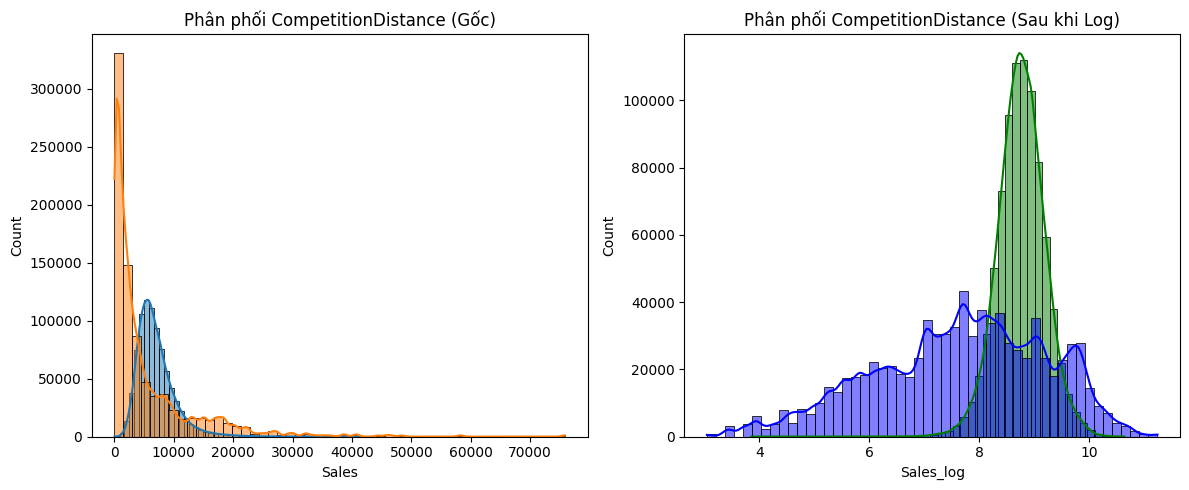

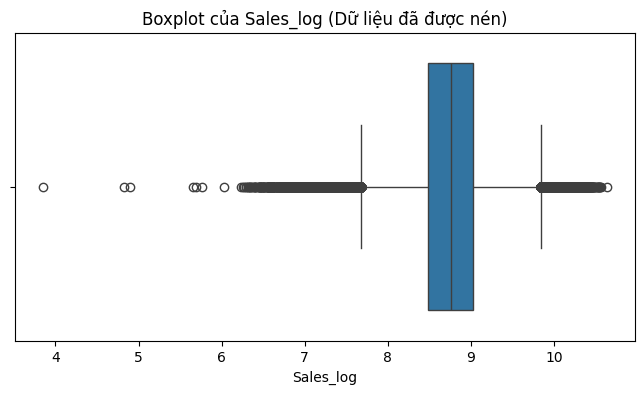

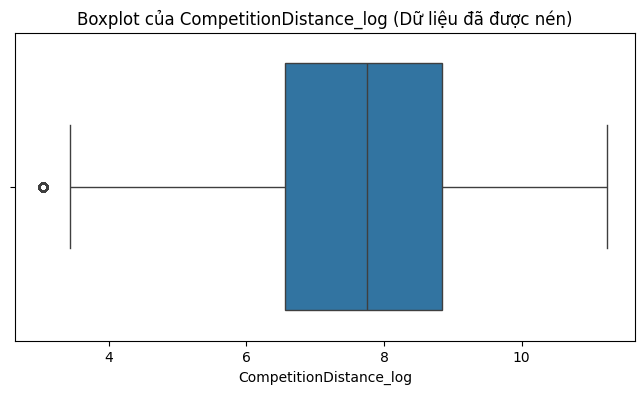

In [2136]:
import numpy as np

# 2. Áp dụng Log Transformation (log1p = log(1+x) để tránh lỗi nếu có giá trị 0)
train_merged['Sales_log'] = np.log1p(train_merged['Sales'])
train_merged['CompetitionDistance_log'] = np.log1p(train_merged['CompetitionDistance'])
# 3. Kiểm tra lại sự thay đổi bằng biểu đồ
plt.figure(figsize=(12, 5))

# Biểu đồ trước khi Log
plt.subplot(1, 2, 1)
sns.histplot(train_merged['Sales'], kde=True, bins=50)
plt.title('Phân phối Sales (Gốc)')

plt.subplot(1, 2, 1)
sns.histplot(train_merged['CompetitionDistance'], kde=True, bins=50)
plt.title('Phân phối CompetitionDistance (Gốc)')

# Biểu đồ sau khi Log
plt.subplot(1, 2, 2)
sns.histplot(train_merged['Sales_log'], kde=True, bins=50, color='green')
plt.title('Phân phối Sales (Sau khi Log)')

plt.subplot(1, 2, 2)
sns.histplot(train_merged['CompetitionDistance_log'], kde=True, bins=50, color='blue')
plt.title('Phân phối CompetitionDistance (Sau khi Log)')
plt.tight_layout()
plt.show()

# 4. Xem lại Boxplot để thấy Outlier đã được "thu phục" như thế nào
plt.figure(figsize=(8, 4))
sns.boxplot(x=train_merged['Sales_log'])
plt.title('Boxplot của Sales_log (Dữ liệu đã được nén)')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=train_merged['CompetitionDistance_log'])
plt.title('Boxplot của CompetitionDistance_log (Dữ liệu đã được nén)')
plt.show()


In [2137]:
import numpy as np

# Giả sử tên cột của bạn là 'CompetitionDistance_log'
column_name = 'CompetitionDistance_log'

# Bước 1: Tính toán các phân vị và khoảng cách IQR
Q1 = train_merged[column_name].quantile(0.25)
Q3 = train_merged[column_name].quantile(0.75)
IQR = Q3 - Q1

# Bước 2: Xác định ngưỡng (Bounds)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Bước 3: Lọc ra các dòng bị coi là Outlier
outliers_df = train_merged[(train_merged[column_name] < lower_bound) | (train_merged[column_name] > upper_bound)]

# Bước 4: Hiển thị kết quả
print(f"--- Thống kê Outlier cho {column_name} ---")
print(f"Ngưỡng dưới (Lower Bound): {lower_bound:.2f}")
print(f"Ngưỡng trên (Upper Bound): {upper_bound:.2f}")
print(f"Số lượng dòng bị coi là outlier: {len(outliers_df)}")
print("-" * 30)

# Xem các giá trị log duy nhất bị coi là outlier
print("Các giá trị Log bị coi là Outlier:")
print(outliers_df[column_name].unique())

# Nếu bạn muốn xem giá trị mét (m) gốc tương ứng:
print("\nGiá trị khoảng cách (mét) gốc tương ứng:")
print(np.expm1(outliers_df[column_name].unique()).round(0))

--- Thống kê Outlier cho CompetitionDistance_log ---
Ngưỡng dưới (Lower Bound): 3.16
Ngưỡng trên (Upper Bound): 12.24
Số lượng dòng bị coi là outlier: 779
------------------------------
Các giá trị Log bị coi là Outlier:
[3.04452244]

Giá trị khoảng cách (mét) gốc tương ứng:
[20.]


- Thay vì cắt bỏ hay sửa dữ liệu, ta dùng hàm Logarit. Đây là cách "nhốt" Outlier vào một cái lồng hẹp hơn.Công thức:
    $$Sales_{log} = \ln(Sales + 1)$$
Tại sao: Nó biến phân phối bị lệch (nhiều outlier) về gần với phân phối chuẩn (Gaussian). Mô hình sẽ không bị "choáng" bởi con số 40,000 nữa vì sau khi Log, nó chỉ còn loanh quanh con số 10.

- Cột Sales: Dùng để chúng ta soi, kiểm tra và tính toán thực tế (human-readable).

- Cột Sales_log: Dùng làm Target (biến mục tiêu) để đưa vào các thuật toán Machine Learning (AI-readable).

Text(0.5, 1.0, 'Phân phối Distance (Gốc)')

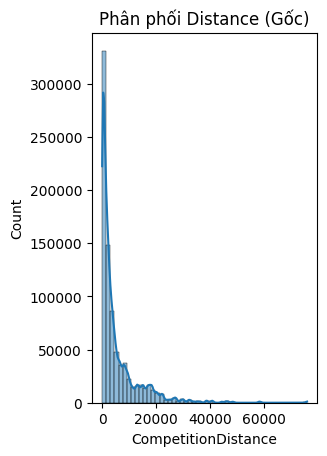

In [2138]:
# Biểu đồ trước khi Log
plt.subplot(1, 2, 1)
sns.histplot(train_merged['CompetitionDistance'], kde=True, bins=50)
plt.title('Phân phối Distance (Gốc)')

In [2139]:
train_merged['CompetitionDistance'].max()

np.float64(75860.0)

In [2140]:
# # import numpy as np

# def add_area_density_feature(train_df, test_df):
#     train_df = train_df.copy()
#     test_df = test_df.copy()
    
#     # ================================
#     # 1. TÍNH STORE PERFORMANCE (TRAIN ONLY)
#     # ================================
    
#     store_sales = (
#         train_df.groupby('Store')['Sales']
#         .mean()
#         .reset_index()
#         .rename(columns={'Sales': 'Avg_Sales_Store'})
#     )
    
#     # global mean
#     global_sales_mean = store_sales['Avg_Sales_Store'].mean()
    
#     # merge
#     train_df = train_df.merge(store_sales, on='Store', how='left')
#     test_df = test_df.merge(store_sales, on='Store', how='left')
    
#     # ================================
#     # 2. CONDITION
#     # ================================
    
#     dist_threshold = 1000
    
#     is_close_comp_train = train_df['CompetitionDistance'] < dist_threshold
#     is_close_comp_test = test_df['CompetitionDistance'] < dist_threshold
    
#     is_high_perf_train = train_df['Avg_Sales_Store'] > global_sales_mean
#     is_high_perf_test = test_df['Avg_Sales_Store'] > global_sales_mean
    
#     # ================================
#     # 3. CREATE FEATURE
#     # ================================
    
#     train_df['Area_Density_Type'] = 0
#     train_df.loc[is_close_comp_train & is_high_perf_train, 'Area_Density_Type'] = 3
#     train_df.loc[is_close_comp_train & ~is_high_perf_train, 'Area_Density_Type'] = 2
#     train_df.loc[~is_close_comp_train & is_high_perf_train, 'Area_Density_Type'] = 1
    
#     test_df['Area_Density_Type'] = 0
#     test_df.loc[is_close_comp_test & is_high_perf_test, 'Area_Density_Type'] = 3
#     test_df.loc[is_close_comp_test & ~is_high_perf_test, 'Area_Density_Type'] = 2
#     test_df.loc[~is_close_comp_test & is_high_perf_test, 'Area_Density_Type'] = 1
    
#     # ================================
#     # 4. DROP
#     # ================================
    
#     train_df.drop(columns=['Avg_Sales_Store'], inplace=True)
#     test_df.drop(columns=['Avg_Sales_Store'], inplace=True)
    
#     return train_df, test_df
# train_merged, test_merged = add_area_density_feature(train_merged, test_merged)

In [2141]:
train_merged

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,CompetitionDistance_log
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9,2008,0,0,0,None,8.568646,7.147559
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct",8.710290,6.347389
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct",9.025816,9.556126
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9,2009,0,0,0,None,9.546527,6.431331
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4,2015,0,0,0,None,8.481151,10.305982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1,b,a,150.0,9,2006,0,0,0,None,8.124447,5.017280
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,b,b,860.0,10,1999,0,0,0,None,9.284148,6.758095
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,b,b,840.0,0,0,1,48,2012,"Jan,Apr,Jul,Oct",8.524367,6.734592
1017042,948,2,2013-01-01,4491,1039,1,0,a,1,b,b,1430.0,0,0,0,0,0,None,8.410053,7.266129


In [2142]:
train_merged['Customers'].value_counts()

Customers
560     2414
576     2363
603     2337
571     2330
555     2328
        ... 
4067       1
7388       1
3900       1
36         1
4065       1
Name: count, Length: 4083, dtype: int64

- Nếu xử lý thì để sau ( CompetitionDistance)

## Feature Engineering

In [2143]:
train_merged.info()

<class 'pandas.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[us]
 3   Sales                      844338 non-null  int64         
 4   Customers                  844338 non-null  int64         
 5   Open                       844338 non-null  int64         
 6   Promo                      844338 non-null  int64         
 7   StateHoliday               844338 non-null  category      
 8   SchoolHoliday              844338 non-null  int64         
 9   StoreType                  844338 non-null  category      
 10  Assortment                 844338 non-null  category      
 11  CompetitionDistance        844338 non-null  float64       
 12  Com

In [2144]:
# numeric_feature  = train_merged.select_dtypes(include=['int64','int8','int16', 'float64']).columns.tolist()
# print("Numeric features:", numeric_feature)

# # category_feature = train_merged.select_dtypes(include=['object']).columns.tolist()
# print("Categorical features:", category_feature)

In [2145]:
# # 1. Tự động lấy danh sách dựa trên kiểu dữ liệu (Dtype)
# numeric_features = train_merged.select_dtypes(include=['float64', 'float32']).columns.tolist()
# categorical_features = train_merged.select_dtypes(include=['category', 'object']).columns.tolist()

# # 2. Xử lý các cột "nửa nạc nửa mỡ" 
# # Những cột là int64 nhưng bản chất là ID hoặc Cờ (Flags) - nên coi là categorical
# discrete_categoricals = [
#     'Store', 'DayOfWeek', 'Open', 'Promo', 
#     'SchoolHoliday', 'Promo2', 'CompetitionOpenSinceMonth', 
#     'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear'
# # ]

# # Đưa chúng vào đúng hàng ngũ
# for col in discrete_categoricals:
#     if col in numeric_features:
#         numeric_features.remove(col)
#     if col not in categorical_features:
#         categorical_features.append(col)

# # 3. Loại bỏ các biến mục tiêu (Target) khỏi danh sách Feature
# targets = ['Sales', 'Customers', 'Sales_log']
# numeric_features = [f for f in numeric_features if f not in targets]

# print(f"✅ Numeric Features ({len(numeric_features)}): {numeric_features}")
# print(f"✅ Categorical Features ({len(categorical_features)}): {categorical_features}")

- Year, Month, Day, DayOfWeek:

Tại sao: Doanh thu bán lẻ có tính chu kỳ cực cao. Ví dụ: Doanh thu tăng vọt vào thứ 2 (đầu tuần làm việc) và thứ 6 (chuẩn bị cuối tuần). Tháng 12 luôn có doanh thu cao nhất do Giáng sinh.

- WeekOfYear:

Tại sao: Giúp mô hình bắt được các hiệu ứng mùa vụ theo tuần mà cột Month hay Day không thể hiện rõ (ví dụ: các tuần lễ mua sắm cao điểm trước nghỉ lễ).

- IsMonthStart, IsMonthEnd:

Tại sao: Thực tế tại Đức và nhiều nơi, người dân thường nhận lương vào cuối tháng hoặc đầu tháng. Điều này dẫn đến sức mua tăng vọt (Sales spikes) vào các ngày này.

In [2146]:
#kiểm tra những ngày lễ Sales có cái nào = 0 không
train_merged[(train_merged['StateHoliday'] != '0') & (train_merged['Sales'] > 0)]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,CompetitionDistance_log
63559,5,4,2015-06-04,5807,625,1,1,a,0,a,a,29910.0,4,2015,0,0,0,None,8.666992,10.305982
63560,6,4,2015-06-04,5749,614,1,1,a,0,a,a,310.0,12,2013,0,0,0,None,8.656955,5.739793
63609,55,4,2015-06-04,5984,702,1,1,a,0,a,a,720.0,11,2004,0,0,0,None,8.697012,6.580639
63611,57,4,2015-06-04,9301,870,1,1,a,0,d,c,420.0,6,2014,0,0,0,None,9.137985,6.042633
63614,60,4,2015-06-04,10399,850,1,1,a,0,d,c,5540.0,10,2009,0,0,0,None,9.249561,8.619930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1,b,a,150.0,9,2006,0,0,0,None,8.124447,5.017280
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,b,b,860.0,10,1999,0,0,0,None,9.284148,6.758095
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,b,b,840.0,0,0,1,48,2012,"Jan,Apr,Jul,Oct",8.524367,6.734592
1017042,948,2,2013-01-01,4491,1039,1,0,a,1,b,b,1430.0,0,0,0,0,0,None,8.410053,7.266129


In [2147]:
#Bỏ cột Customers và Open
train_merged = train_merged.drop(columns=['Customers', 'Open'])

In [2148]:
train_merged

,Store,DayOfWeek,Date,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,CompetitionDistance_log
0,1,5,2015-07-31,5263,1,0,1,c,a,1270.0,9,2008,0,0,0,None,8.568646,7.147559
1,2,5,2015-07-31,6064,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct",8.710290,6.347389
2,3,5,2015-07-31,8314,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct",9.025816,9.556126
3,4,5,2015-07-31,13995,1,0,1,c,c,620.0,9,2009,0,0,0,None,9.546527,6.431331
4,5,5,2015-07-31,4822,1,0,1,a,a,29910.0,4,2015,0,0,0,None,8.481151,10.305982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,0,a,1,b,a,150.0,9,2006,0,0,0,None,8.124447,5.017280
1016827,733,2,2013-01-01,10765,0,a,1,b,b,860.0,10,1999,0,0,0,None,9.284148,6.758095
1016863,769,2,2013-01-01,5035,0,a,1,b,b,840.0,0,0,1,48,2012,"Jan,Apr,Jul,Oct",8.524367,6.734592
1017042,948,2,2013-01-01,4491,0,a,1,b,b,1430.0,0,0,0,0,0,None,8.410053,7.266129


In [2149]:
# #kiểm tra Store 4 xem sale 5 ngày  đầu tháng với 5 ngày cuối tháng có khác nhau không
# store_4 = train_merged[train_merged['Store'] == 622]
# first_5_days = store_4[store_4['Day'].isin([1, 2, 3, 4, 5])]
# last_5_days = store_4[store_4['Day'].isin([store_4['Day'].iloc[0] - 4, store_4['Day'].iloc[0] - 3, store_4['Day'].iloc[0] - 2, store_4['Day'].iloc[0] - 1, store_4['Day'].iloc[0]])]

# print("Sum Sales 5 ngày đầu tháng:", first_5_days["Sales"].sum())
# print("Sum Sales 5 ngày cuối tháng:", last_5_days["Sales"].sum())

# # #kiểm tra xem toàn bộ store có tuân theo pattern này không
# # stores = train_merged['Store'].unique()
# # for store in stores:
# #     store_data = train_merged[train_merged['Store'] == store]
# #     first_5_days = store_data[store_data['Day'].isin([1, 2, 3, 4, 5])]
# #     last_5_days = store_data[store_data['Day'].isin([store_data['Day'].iloc[0] - 4, store_data['Day'].iloc[0] - 3, store_data['Day'].iloc[0] - 2, store_data['Day'].iloc[0] - 1, store_data['Day'].iloc[0]])]
    
# #     sum_first_5 = first_5_days["Sales"].sum()
# #     sum_last_5 = last_5_days["Sales"].sum()
    
# #     if sum_first_5 > sum_last_5:
# #         print(f"Store {store}: Sum Sales 5 ngày đầu tháng ({sum_first_5:.2f}) > Sum Sales 5 ngày cuối tháng ({sum_last_5:.2f})")
# #     else:
# #         print(f"Store {store}: Sum Sales 5 ngày đầu tháng ({sum_first_5:.2f}) <= Sum Sales 5 ngày cuối tháng ({sum_last_5:.2f})")

# #đếm xem có bao nhiêu store có đầu tháng lớn hơn và bao nhiêu store có đầu tháng nhỏ hơn hoặc bằng cuối tháng
# count_first_greater = 0
# count_first_less_equal = 0
# stores = train_merged['Store'].unique()
# for store in stores:
#     store_data = train_merged[train_merged['Store'] == store]
#     first_5_days = store_data[store_data['Day'].isin([1, 2, 3, 4, 5])]
#     last_5_days = store_data[store_data['Day'].isin([store_data['Day'].iloc[0] - 4, store_data['Day'].iloc[0] - 3, store_data['Day'].iloc[0] - 2, store_data['Day'].iloc[0] - 1, store_data['Day'].iloc[0]])]
    
#     sum_first_5 = first_5_days["Sales"].sum()
#     sum_last_5 = last_5_days["Sales"].sum()
    
#     if sum_first_5 > sum_last_5:
#         count_first_greater += 1
#     else:
#         count_first_less_equal += 1

# count_first_greater,count_first_less_equal

In [2150]:
train_merged

,Store,DayOfWeek,Date,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,CompetitionDistance_log
0,1,5,2015-07-31,5263,1,0,1,c,a,1270.0,9,2008,0,0,0,None,8.568646,7.147559
1,2,5,2015-07-31,6064,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct",8.710290,6.347389
2,3,5,2015-07-31,8314,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct",9.025816,9.556126
3,4,5,2015-07-31,13995,1,0,1,c,c,620.0,9,2009,0,0,0,None,9.546527,6.431331
4,5,5,2015-07-31,4822,1,0,1,a,a,29910.0,4,2015,0,0,0,None,8.481151,10.305982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,0,a,1,b,a,150.0,9,2006,0,0,0,None,8.124447,5.017280
1016827,733,2,2013-01-01,10765,0,a,1,b,b,860.0,10,1999,0,0,0,None,9.284148,6.758095
1016863,769,2,2013-01-01,5035,0,a,1,b,b,840.0,0,0,1,48,2012,"Jan,Apr,Jul,Oct",8.524367,6.734592
1017042,948,2,2013-01-01,4491,0,a,1,b,b,1430.0,0,0,0,0,0,None,8.410053,7.266129


In [2151]:
train_merged[train_merged['CompetitionDistance'] < 2000 ]

,Store,DayOfWeek,Date,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,CompetitionDistance_log
0,1,5,2015-07-31,5263,1,0,1,c,a,1270.0,9,2008,0,0,0,None,8.568646,7.147559
1,2,5,2015-07-31,6064,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct",8.710290,6.347389
3,4,5,2015-07-31,13995,1,0,1,c,c,620.0,9,2009,0,0,0,None,9.546527,6.431331
5,6,5,2015-07-31,5651,1,0,1,a,a,310.0,12,2013,0,0,0,None,8.639765,5.739793
10,11,5,2015-07-31,10457,1,0,1,a,c,960.0,11,2011,1,1,2012,"Jan,Apr,Jul,Oct",9.255123,6.867974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,0,a,1,b,a,150.0,9,2006,0,0,0,None,8.124447,5.017280
1016827,733,2,2013-01-01,10765,0,a,1,b,b,860.0,10,1999,0,0,0,None,9.284148,6.758095
1016863,769,2,2013-01-01,5035,0,a,1,b,b,840.0,0,0,1,48,2012,"Jan,Apr,Jul,Oct",8.524367,6.734592
1017042,948,2,2013-01-01,4491,0,a,1,b,b,1430.0,0,0,0,0,0,None,8.410053,7.266129


In [2152]:
#kiểm tra xem có trường hợp nào promo =1 và promo2 = 1 không
train_merged[(train_merged['Promo'] == 1) & (train_merged['Promo2'] == 1)]['Sales'].describe()

count    187870.000000
mean       7836.672987
std        2818.324929
min         800.000000
25%        5863.000000
50%        7358.000000
75%        9235.000000
max       37646.000000
Name: Sales, dtype: float64

In [2153]:
train_merged['Sales'].min()

np.int64(46)

In [2154]:
train_merged[train_merged['Store']==1]

,Store,DayOfWeek,Date,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,CompetitionDistance_log
0,1,5,2015-07-31,5263,1,0,1,c,a,1270.0,9,2008,0,0,0,None,8.568646,7.147559
1115,1,4,2015-07-30,5020,1,0,1,c,a,1270.0,9,2008,0,0,0,None,8.521384,7.147559
2230,1,3,2015-07-29,4782,1,0,1,c,a,1270.0,9,2008,0,0,0,None,8.472823,7.147559
3345,1,2,2015-07-28,5011,1,0,1,c,a,1270.0,9,2008,0,0,0,None,8.519590,7.147559
4460,1,1,2015-07-27,6102,1,0,1,c,a,1270.0,9,2008,0,0,0,None,8.716536,7.147559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009405,1,1,2013-01-07,7176,1,0,1,c,a,1270.0,9,2008,0,0,0,None,8.878637,7.147559
1011635,1,6,2013-01-05,4997,0,0,1,c,a,1270.0,9,2008,0,0,0,None,8.516793,7.147559
1012750,1,5,2013-01-04,4486,0,0,1,c,a,1270.0,9,2008,0,0,0,None,8.408940,7.147559
1013865,1,4,2013-01-03,4327,0,0,1,c,a,1270.0,9,2008,0,0,0,None,8.372861,7.147559


In [2155]:
# train_merged['Month'].unique()

In [2156]:
train_merged['PromoInterval'].unique()

['None', 'Jan,Apr,Jul,Oct', 'Feb,May,Aug,Nov', 'Mar,Jun,Sept,Dec']
Categories (4, str): ['Feb,May,Aug,Nov', 'Jan,Apr,Jul,Oct', 'Mar,Jun,Sept,Dec', 'None']

In [2157]:
train_merged.info()

<class 'pandas.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[us]
 3   Sales                      844338 non-null  int64         
 4   Promo                      844338 non-null  int64         
 5   StateHoliday               844338 non-null  category      
 6   SchoolHoliday              844338 non-null  int64         
 7   StoreType                  844338 non-null  category      
 8   Assortment                 844338 non-null  category      
 9   CompetitionDistance        844338 non-null  float64       
 10  CompetitionOpenSinceMonth  844338 non-null  int8          
 11  CompetitionOpenSinceYear   844338 non-null  int16         
 12  Pro

In [2158]:
train_merged[train_merged['Sales'] == 46 ]

,Store,DayOfWeek,Date,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,CompetitionDistance_log
273387,652,6,2014-11-22,46,0,0,0,a,a,20390.0,0,0,0,0,0,None,3.850148,9.922849


In [2159]:
train_merged[train_merged['StateHoliday'] != '0'].head(10)

,Store,DayOfWeek,Date,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,CompetitionDistance_log
63559,5,4,2015-06-04,5807,1,a,0,a,a,29910.0,4,2015,0,0,0,None,8.666992,10.305982
63560,6,4,2015-06-04,5749,1,a,0,a,a,310.0,12,2013,0,0,0,None,8.656955,5.739793
63609,55,4,2015-06-04,5984,1,a,0,a,a,720.0,11,2004,0,0,0,None,8.697012,6.580639
63611,57,4,2015-06-04,9301,1,a,0,d,c,420.0,6,2014,0,0,0,None,9.137985,6.042633
63614,60,4,2015-06-04,10399,1,a,0,d,c,5540.0,10,2009,0,0,0,None,9.249561,8.619930
63649,95,4,2015-06-04,8317,1,a,0,a,a,1890.0,10,2014,0,0,0,None,9.026177,7.544861
63650,96,4,2015-06-04,6573,1,a,0,a,a,8780.0,2,2005,1,37,2009,"Jan,Apr,Jul,Oct",8.790878,9.080346
63651,97,4,2015-06-04,8519,1,a,0,d,c,8980.0,0,0,0,0,0,None,9.050172,9.102867
63675,121,4,2015-06-04,5191,1,a,0,a,a,3570.0,11,2009,1,36,2013,"Mar,Jun,Sept,Dec",8.554874,8.180601
63692,138,4,2015-06-04,9485,1,a,0,a,c,25360.0,10,2014,0,0,0,None,9.157572,10.140968


In [2160]:
train_merged['Promo2'].value_counts()

Promo2
0    423292
1    421046
Name: count, dtype: int64

In [2161]:
train_merged.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
Sales_log                    0
CompetitionDistance_log      0
dtype: int64

In [2162]:
train_merged[train_merged['Date'] == 0] 

,Store,DayOfWeek,Date,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,CompetitionDistance_log


In [2163]:
train_merged.info()

<class 'pandas.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[us]
 3   Sales                      844338 non-null  int64         
 4   Promo                      844338 non-null  int64         
 5   StateHoliday               844338 non-null  category      
 6   SchoolHoliday              844338 non-null  int64         
 7   StoreType                  844338 non-null  category      
 8   Assortment                 844338 non-null  category      
 9   CompetitionDistance        844338 non-null  float64       
 10  CompetitionOpenSinceMonth  844338 non-null  int8          
 11  CompetitionOpenSinceYear   844338 non-null  int16         
 12  Pro

## 📊 Giải Thích Các Đặc Trưng (Feature Engineering) - Rossmann Store Sales

Bản danh sách này giải thích logic đằng sau các đặc trưng (features) được trích xuất từ hàm build_features.  

Mục tiêu là chuyển đổi dữ liệu thô thành các tín hiệu có nghĩa để mô hình Machine Learning hiểu được bối cảnh kinh doanh.

---

### 1. Nhóm Khuyến Mãi (Promotions)

- Nhóm này giúp mô hình phân biệt giữa các đợt kích cầu ngắn hạn và dài hạn.

- **IsPromo2Month (Binary):**  
  Ý nghĩa: Xác định ngày hiện tại có thực sự rơi vào tháng có hiệu lực của chương trình Promo2 hay không.  
  Logic: So khớp tháng của giao dịch với danh sách các tháng khuyến mãi trong *PromoInterval*.

- **Promo2OpenWeeks (Continuous):**  
  + Ý nghĩa: Đo lường "độ tươi" (tuổi đời) của chương trình khuyến mãi dài hạn tính theo tuần.  
  + Tại sao cần: Khách hàng thường hào hứng với khuyến mãi mới và bị "lờn" (bão hòa) nếu khuyến mãi đã chạy quá lâu.

- **promo_interaction (Interaction):**  
  + Ý nghĩa: Sự kết hợp giữa Promo (ngắn hạn) và IsPromo2Month (dài hạn).  
  + Giá trị: Đây là biến "Siêu khuyến mãi". Khi cả hai loại khuyến mãi cùng xuất hiện, doanh số thường có xu hướng bùng nổ mạnh hơn tổng mức tăng của từng cái cộng lại.

---

### 2. Nhóm Đối Thủ Cạnh Tranh (Competition)

- Nhóm này tập trung vào áp lực từ các đối thủ xung quanh Store.

- **competition_open_months (Continuous):**  
  + Ý nghĩa: Thời gian (số tháng) kể từ khi đối thủ cạnh tranh khai trương.  
  + Tại sao cần: Một đối thủ mới mở (dưới 3 tháng) thường gây sụt giảm doanh số mạnh do khách hàng tò mò đi dùng thử.

- **competition_impact (Weighting Score):**  
  + Công thức:  

$$
\text{competition\_impact} = \frac{(\text{competition\_open\_months} \le 3)}{\text{CompetitionDistance} + 1}
$$

  + Ý nghĩa: Đây là chỉ số áp lực thực tế. Nếu đối thủ mới mở nhưng ở quá xa, chỉ số này tiến về 0. Nếu đối thủ mới mở và ở sát vách, chỉ số này sẽ rất cao, báo hiệu Sales sẽ giảm.

---

### 3. Nhóm Đặc Điểm Cửa Hàng (Store Metadata)

- Sử dụng kỹ thuật One-Hot Encoding để phân loại bản chất của từng địa điểm kinh doanh.

- **StoreType_...:**  
  + Phân loại cửa hàng theo mô hình kinh doanh (ví dụ: StoreType_b thường là các cửa hàng tại nhà ga/sân bay, có doanh số ổn định và mở cửa cả ngày lễ).

- **Assortment_...:**  
  + Phân loại theo danh mục hàng hóa (Cơ bản - Vừa - Mở rộng). Giúp mô hình hiểu được giá trị đơn hàng trung bình của từng nơi.  
  + drop_first=True:Kỹ thuật loại bỏ cột đầu tiên trong Encoding để tránh bẫy đa cộng tuyến (Multicollinearity), giúp mô hình toán học chạy ổn định hơn.

In [2164]:
def extract_row_logic(df):
    df = df.copy()
    
    # 1. Date Components
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['IsWeekend'] = df['Date'].dt.weekday.isin([5, 6]).astype(int)
    
    # --- FEATURE HOLIDAY DUY NHẤT (0 hoặc 1) ---
    # Hễ có StateHoliday (a,b,c) HOẶC SchoolHoliday (1) thì tính là 1
    df['is_holiday'] = ((df['StateHoliday'] != '0') | (df['SchoolHoliday'] == 1)).astype(int)

    # 2. Promo2 logic
    month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
    df['MonthStr'] = df['Month'].map(month_map)
    
    df['IsPromo2Month'] = ((df['Promo2'] == 1) & 
                           (df['MonthStr'].isin(df['PromoInterval'].fillna('').str.split(',')))).astype(int)
    
    # Promo2 duration
    df['Promo2OpenWeeks'] = 0.0
    mask_p2 = (df['Promo2'] == 1) & (df['Promo2SinceYear'] > 0) & (df['Promo2SinceWeek'] > 0)
    p2_start = pd.to_datetime(df.loc[mask_p2, 'Promo2SinceYear'].astype(str) + '-' + 
                              df.loc[mask_p2, 'Promo2SinceWeek'].astype(str) + '-1', 
                              format='%Y-%W-%w', errors='coerce')
    df.loc[mask_p2, 'Promo2OpenWeeks'] = ((df.loc[mask_p2, 'Date'] - p2_start).dt.days / 7).clip(lower=0)

    # Tương tác Promo và Holiday
    df['promo_holiday'] = df['Promo'] * df['is_holiday']
    
    # 3. Competition logic
    df['competition_open_months'] = 0.0
    mask_c = (df['CompetitionOpenSinceYear'] > 0) & (df['CompetitionOpenSinceMonth'] > 0)
    c_start = pd.to_datetime(df.loc[mask_c, 'CompetitionOpenSinceYear'].astype(str) + '-' + 
                             df.loc[mask_c, 'CompetitionOpenSinceMonth'].astype(str) + '-1', errors='coerce')
    df.loc[mask_c, 'competition_open_months'] = ((df.loc[mask_c, 'Date'] - c_start).dt.days / 30).clip(lower=0)
    
    df['promo_interaction'] = df['Promo'] * df['IsPromo2Month']
    
    return df

# Chạy cho cả 2 tập dữ liệu ban đầu
train_processed = extract_row_logic(train_merged)
test_processed = extract_row_logic(test_merged)

In [2165]:
from sklearn.preprocessing import OneHotEncoder

# 1. Tính toán Competition Impact (Dựa trên Distance đã được điền khuyết trước đó)
for df in [train_processed, test_processed]:
    # Tạo CompetitionDistance_log để thu hẹp khoảng cách outlier
    df['CompetitionDistance_log'] = np.log1p(df['CompetitionDistance'])
    # Tính Impact dựa trên cột Distance gốc để giữ ý nghĩa thực tế
    df['competition_impact'] = ((df['competition_open_months'] <= 3).astype(int) / 
                                (df['CompetitionDistance'] + 1)) 

# 2. Mã hóa StoreType & Assortment bằng OneHotEncoder
# Khởi tạo ohe (Fit trên Train để học danh sách các loại cửa hàng)
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe.fit(train_processed[['StoreType', 'Assortment']])

# Hàm áp dụng Encoder
def apply_ohe(df, encoder):
    encoded_cols = encoder.transform(df[['StoreType', 'Assortment']])
    encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(), index=df.index)
    # Gộp lại và xóa cột chữ gốc
    return pd.concat([df.drop(['StoreType', 'Assortment'], axis=1), encoded_df], axis=1)

train_final = apply_ohe(train_processed, ohe)
test_final = apply_ohe(test_processed, ohe)

In [2166]:
def final_drop(df):
    cols_to_drop = [
        'Date', 'Promo2', 'PromoInterval', 'MonthStr', 
        'Promo2SinceWeek', 'Promo2SinceYear',
        'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
        'StateHoliday', 'SchoolHoliday', # Đã gộp thành 'is_holiday'
        'Customers', # 🛑 LEAKAGE CỰC NẶNG: Xóa vì tập Test không bao giờ có cột này
        'CompetitionDistance', # Đã tạo biến log và impact, nên có thể bỏ cột gốc   
    ]
    return df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Thực hiện dọn dẹp cuối cùng
train_final = final_drop(train_final)
test_final = final_drop(test_final)

# Kiểm tra kết quả
print(f"Số cột tập Train: {train_final.shape[1]}")
print(f"Số cột tập Test: {test_final.shape[1]}")

Số cột tập Train: 23
Số cột tập Test: 23


In [2167]:
train_merged.info()

<class 'pandas.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[us]
 3   Sales                      844338 non-null  int64         
 4   Promo                      844338 non-null  int64         
 5   StateHoliday               844338 non-null  category      
 6   SchoolHoliday              844338 non-null  int64         
 7   StoreType                  844338 non-null  category      
 8   Assortment                 844338 non-null  category      
 9   CompetitionDistance        844338 non-null  float64       
 10  CompetitionOpenSinceMonth  844338 non-null  int8          
 11  CompetitionOpenSinceYear   844338 non-null  int16         
 12  Pro

In [2168]:
train_final.info()

<class 'pandas.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 23 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Store                    844338 non-null  int64  
 1   DayOfWeek                844338 non-null  int64  
 2   Sales                    844338 non-null  int64  
 3   Promo                    844338 non-null  int64  
 4   Sales_log                844338 non-null  float64
 5   CompetitionDistance_log  844338 non-null  float64
 6   Year                     844338 non-null  int32  
 7   Month                    844338 non-null  int32  
 8   Day                      844338 non-null  int32  
 9   WeekOfYear               844338 non-null  int64  
 10  IsWeekend                844338 non-null  int64  
 11  is_holiday               844338 non-null  int64  
 12  IsPromo2Month            844338 non-null  int64  
 13  Promo2OpenWeeks          844338 non-null  float64
 14  promo_holiday      

In [2169]:
test_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       41088 non-null  int32  
 1   Store                    41088 non-null  int64  
 2   DayOfWeek                41088 non-null  int64  
 3   Open                     41088 non-null  int64  
 4   Promo                    41088 non-null  int64  
 5   Year                     41088 non-null  int32  
 6   Month                    41088 non-null  int32  
 7   Day                      41088 non-null  int32  
 8   WeekOfYear               41088 non-null  int64  
 9   IsWeekend                41088 non-null  int64  
 10  is_holiday               41088 non-null  int64  
 11  IsPromo2Month            41088 non-null  int64  
 12  Promo2OpenWeeks          41088 non-null  float64
 13  promo_holiday            41088 non-null  int64  
 14  competition_open_months  41088 no

In [2170]:
train_final['Sales']

0           5263
1           6064
2           8314
3          13995
4           4822
           ...  
1016776     3375
1016827    10765
1016863     5035
1017042     4491
1017190     5961
Name: Sales, Length: 844338, dtype: int64

<Axes: >

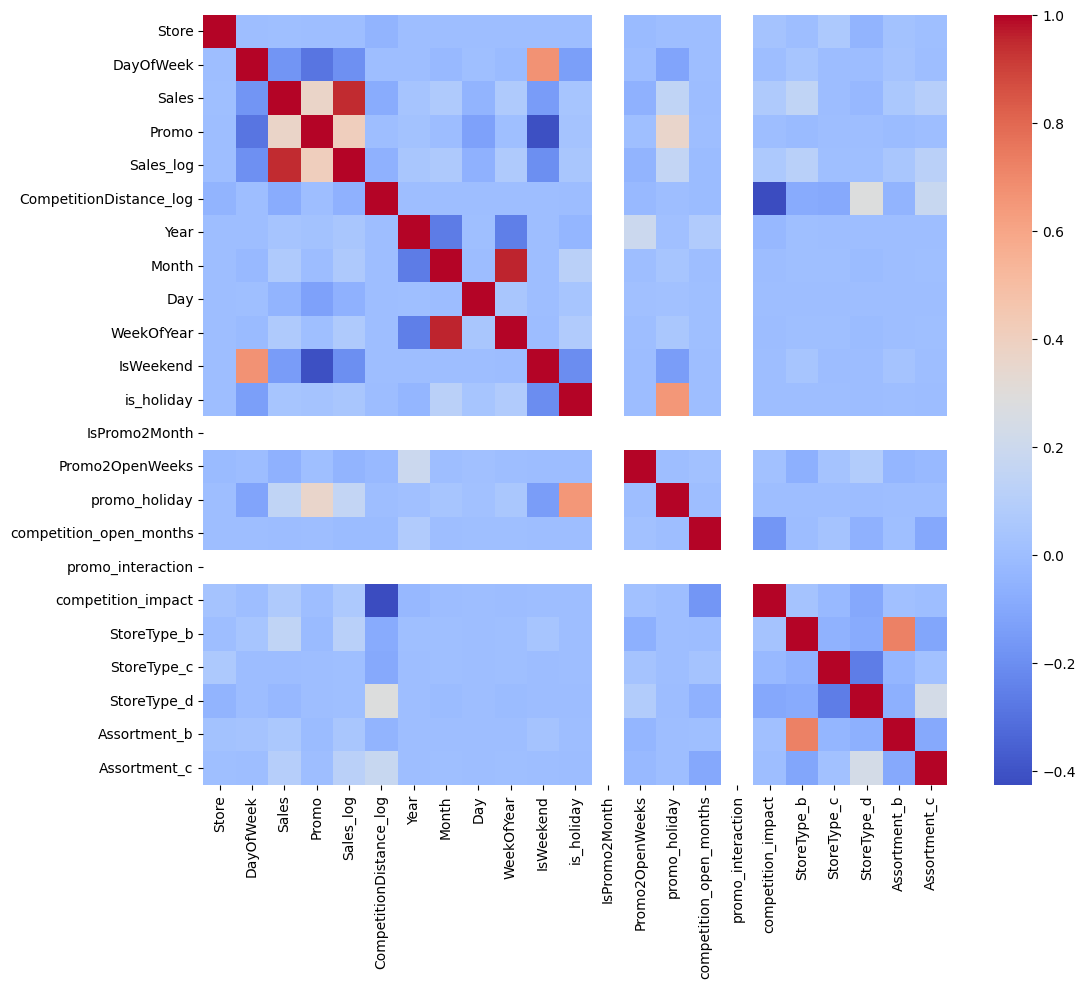

In [2171]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(train_final.corr(), cmap='coolwarm')


### 🟥 (3) Month vs WeekOfYear

👉 Corr khá cao

🧠 Giải thích:
WeekOfYear gần như encode Month rồi
⚖️ Quyết định:
Model	Xử lý
Tree (XGB, RF)	✅ giữ cả 2
Linear	⚠️ cân nhắc drop 1

👉 Với bạn → GIỮ

### 🟥 (4) promo_holiday vs Promo

👉 Corr tương đối cao

🧠 Giải thích:
promo_holiday = Promo * is_holiday

→ phụ thuộc Promo

❗ Nhưng:

👉 KHÔNG drop

👉 Vì:

interaction = thông tin mới
model rất thích


### AE ĐỌC RỒI QUYẾT ĐỊNH FEATURE

In [2172]:
# 1. TÁCH TARGET (KHÔNG LEAKAGE)
y_train = train_final['Sales_log']
X_train = train_final.drop(['Sales', 'Sales_log'], axis=1)


# 3. XỬ LÝ TEST
# =========================

# Lưu lại Id để nộp bài
test_id = test_final['Id']

# Tạo X_test (drop Id vì không phải feature)
X_test = test_final.drop(['Id'], axis=1)

# =========================
# 4. ĐẢM BẢO KHÔNG LỆCH CỘT
# =========================

# # Align columns giữa train và test (CỰC QUAN TRỌNG)
# X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# =========================
# 5. CHECK CUỐI
# =========================
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)

X_train shape: (844338, 21)
X_test shape : (41088, 22)
y_train shape: (844338,)


In [2173]:

# --- A. TẬP TRAIN ---
# Target (y): Dùng Sales_log như ông muốn để trị outlier và khớp chỉ số RMSPE
y_train = train_final['Sales_log']

# Features (X): Loại bỏ tất cả những gì liên quan đến đáp án
# Cấm tiệt: 'Sales', 'Sales_log' và 'Customers' (Leakage cực nặng)
X_train = train_final.drop(columns=['Sales', 'Sales_log'], errors='ignore')


# --- B. TẬP TEST ---
# Với tập Test, ông chỉ cần Features để dự báo
# Phải đảm bảo danh sách cột của X_test y hệt X_train
X_test = test_final.drop(columns=['Id', 'Sales', 'Sales_log', 'Customers', 'Open'], errors='ignore')

# --- C. KIỂM TRA CUỐI CÙNG ---
print(f"✅ X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Kiểm tra lệch cột (Cực kỳ quan trọng)
missing_cols = set(X_train.columns) - set(X_test.columns)
if not missing_cols:
    print("Tuyệt vời! X_train và X_test đã đồng nhất cột.")
else:
    print(f"Cảnh báo: Tập Test thiếu các cột sau: {missing_cols}")

✅ X_train shape: (844338, 21) | y_train shape: (844338,)
✅ X_test shape: (41088, 21)
Tuyệt vời! X_train và X_test đã đồng nhất cột.
